<a href="https://colab.research.google.com/github/jorge-reynam/Reporte-de-atenciones/blob/main/An%C3%A1lisis_PILARES_Marzo_Junio_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Importar las librerías para desarrollar el proyecto

In [2]:
#Importar las librerías

# Análisis de información
import pandas as pd

# Visualización de información
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

### Funciones

#### Importar archivo Excel desde Google Drive

In [21]:
# Función que lee la hoja de cálculo desde la URL

def leer_hoja_google(url, nombre_de_pestaña):
  """
  Esta función lee la hoja de cálculo desde la URL proporcionada y devuelve un DataFrame con los datos.

  Parámetros:
  url (str): La URL de la hoja de cálculo de Google Drive.
  nombre_de_pestaña (str): El nombre de la pestaña de la hoja de cálculo que se desea leer.

  Retorna:
  pd.DataFrame: Un DataFrame con los datos de la hoja de cálculo.
  """
  try:
    nombre_de_hoja = url.split("/d/")[1].split("/")[0]
    csv_url = f"https://docs.google.com/spreadsheets/d/{nombre_de_hoja}/gviz/tq?tqx=out:csv&sheet={nombre_de_pestaña}"
    base_de_datos = pd.read_csv(csv_url)
    print(f"La base de datos ha sido cargada exitosamente")
    return base_de_datos

  except Exception as e:
    print(f"Error al leer la hoja: {e}")
    return None

In [27]:
# Función que devuelve el análisis exploratorio de datos (EDA)

def visualizacion(base_de_datos):
  """
    Esta función devuelve el análisis exploratorio de datos (EDA) de la base de datos proporcionada.

    Parámetros:
    base_pilares (pd.DataFrame): El DataFrame con los datos de la base de datos.

    Retorna:
    None
  """
  print("La base de datos 'Atenciones Marzo-Junio' tiene la siguiente información:")
  print()
  print(base_de_datos.info())
  print()
  print("====================================================================================")
  print("Dimensiones de la base de datos:")
  print()
  print(f"La base tiene {base_de_datos.shape[0]} filas y {base_de_datos.shape[1]} columnas")
  print()
  print("====================================================================================")
  print("La base de datos tiene las siguiente estadísticas:")
  print()
  print(base_de_datos.describe())
  print()
  print("====================================================================================")
  print("La base de datos tiene los siguientes datos ausentes por columna:")
  print()
  print(base_de_datos.isnull().sum())
  print()
  print("====================================================================================")
  print("La base de datos tiene los siguientes porcentajes de datos ausentes por columna:")
  print()

  # Calcular el porcentaje de datos faltantes por columna
  for columna in base_de_datos.columns:
      columna_vacia = base_de_datos[columna].isnull().sum()
      columna_vacia_porc = (columna_vacia / len(base_de_datos)) * 100
      print(f"El porcentaje de datos ausentes para la columna {columna} es: {columna_vacia_porc:.2f}%")
      print()

#### Cargar la base de datos usando la función leer_hoja_google


In [30]:
# Cargar la base de datos y asignar el df de vuelta a un objeto

base_pilares = leer_hoja_google("https://docs.google.com/spreadsheets/d/10bR8fBS-OtYIZVZfA2wC1SYH3CxKJXji/edit?gid=600762499#gid=600762499", "Atenciones_Marzo_Junio_2026")

La base de datos ha sido cargada exitosamente


In [31]:
visualizacion(base_pilares)

La base de datos 'Atenciones Marzo-Junio' tiene la siguiente información:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3938 entries, 0 to 3937
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Fecha          3938 non-null   object
 1   Hora           3938 non-null   int64 
 2   Subido         3938 non-null   bool  
 3   Folio          3938 non-null   object
 4   Observaciones  3768 non-null   object
 5   Actividad      3461 non-null   object
 6   Sexo           3177 non-null   object
dtypes: bool(1), int64(1), object(5)
memory usage: 188.6+ KB
None

Dimensiones de la base de datos:

La base tiene 3938 filas y 7 columnas

La base de datos tiene las siguiente estadísticas:

              Hora
count  3938.000000
mean      2.694769
std       1.133138
min       1.000000
25%       2.000000
50%       3.000000
75%       4.000000
max       4.000000

La base de datos tiene los siguientes datos ausentes por columna:

F

#### Conversión de tipo de datos

In [33]:
# Convertir la columna "Fecha" al tipo datetime

base_pilares["Fecha"] = pd.to_datetime(base_pilares["Fecha"], format="%d/%m/%y")
print(f"La columna 'Fecha' es del tipo: {base_pilares['Fecha'].dtype}")

La columna 'Fecha' es del tipo: datetime64[ns]


#### Observación de datos

In [34]:
# Histórico de atenciones por día
atenciones_diarias = base_pilares.groupby("Fecha").size().reset_index(drop=False)
atenciones_diarias= atenciones_diarias.rename(columns={
    'Fecha' : 'Fecha',
     0 : 'Total'
    })

atenciones_diarias_df = pd.DataFrame(atenciones_diarias)

print(atenciones_diarias_df)

        Fecha  Total
0  2026-03-19     32
1  2026-03-20     46
2  2026-03-21     30
3  2026-03-23     72
4  2026-03-24     30
..        ...    ...
75 2026-06-23     50
76 2026-06-25     50
77 2026-06-26     52
78 2026-06-27     27
79 2026-06-29     34

[80 rows x 2 columns]


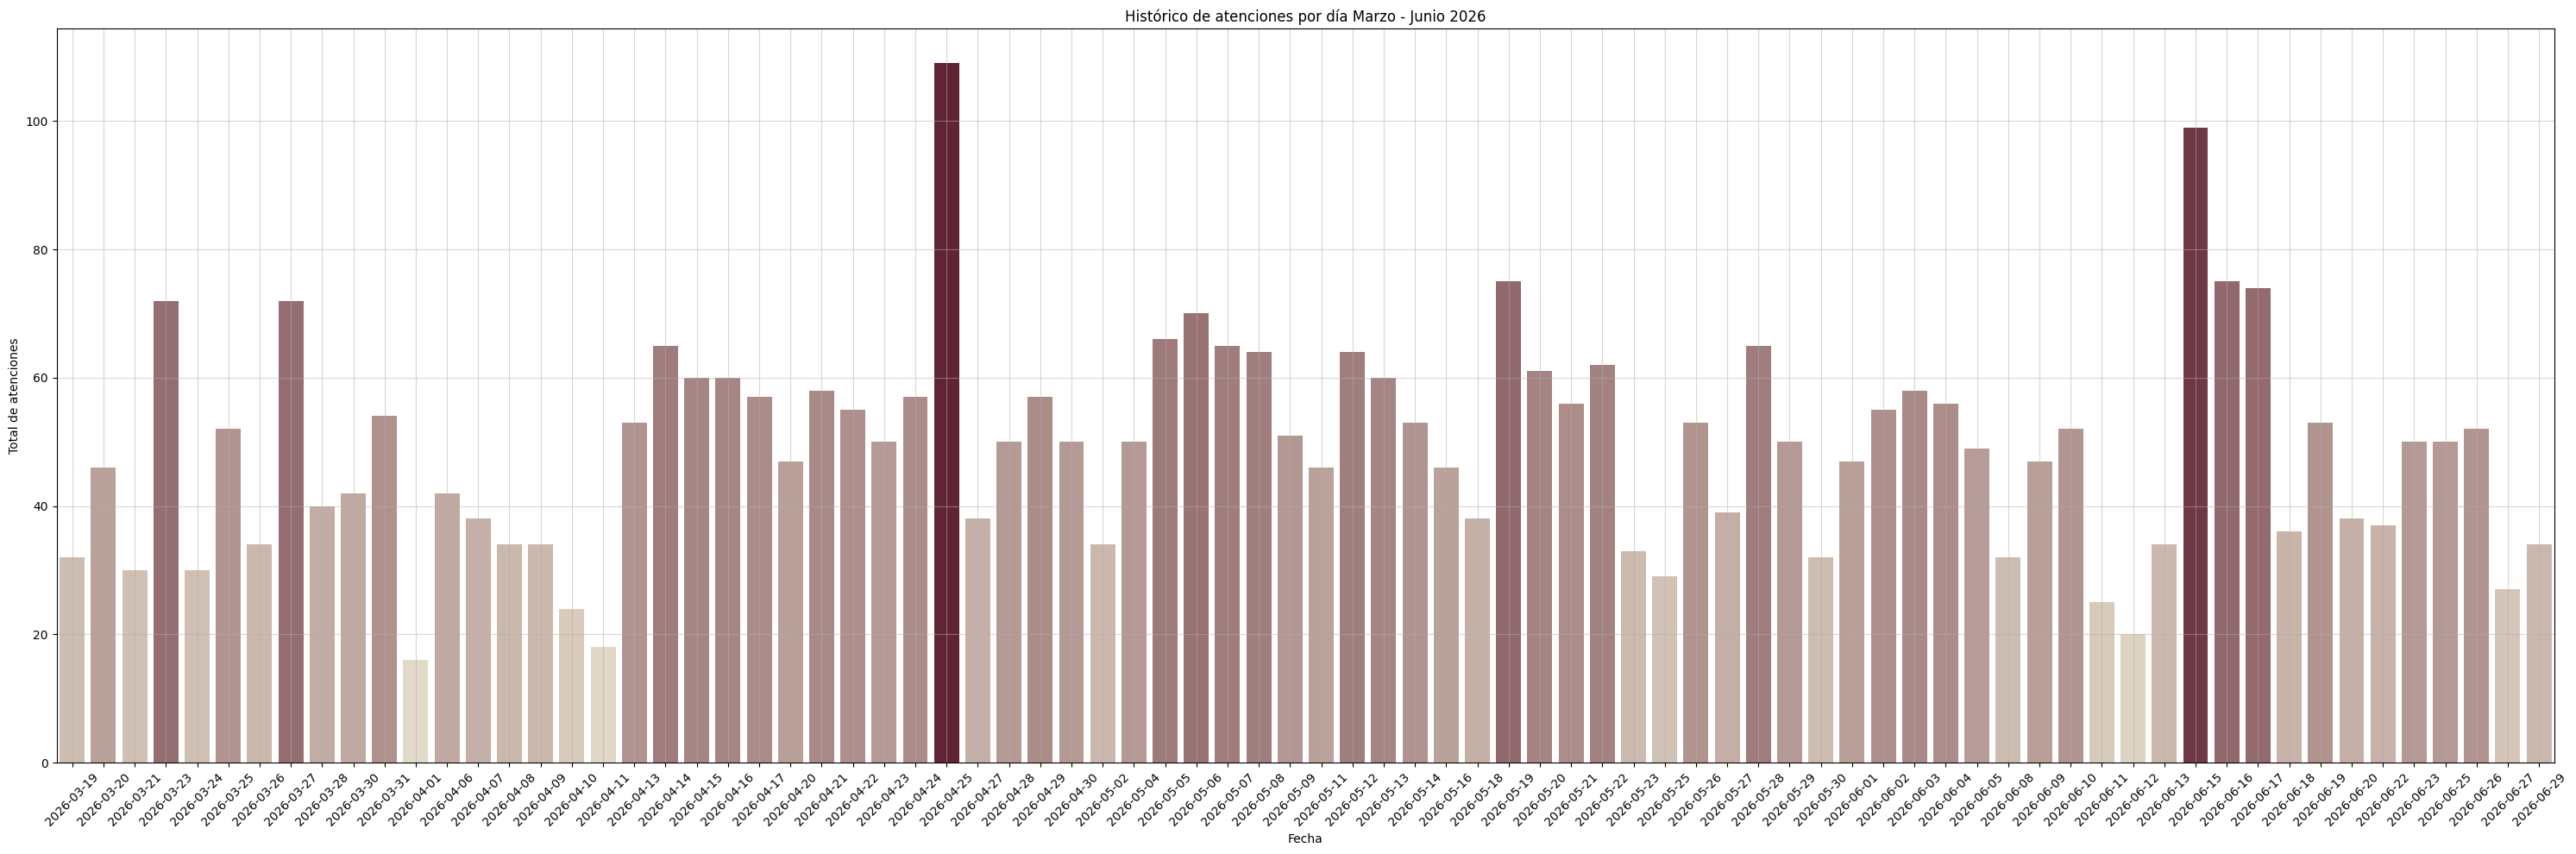

In [35]:
# Histórico de atenciones por día
plt.figure(figsize=(30,10))
sns.barplot(x="Fecha", y="Total", data=atenciones_diarias_df, palette="blend:#E8DCC4,#6A1B31", hue="Total", legend=False)
plt.title("Histórico de atenciones por día Marzo - Junio 2026")
plt.xlabel("Fecha")
plt.ylabel("Total de atenciones")
plt.grid(True, alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

